# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  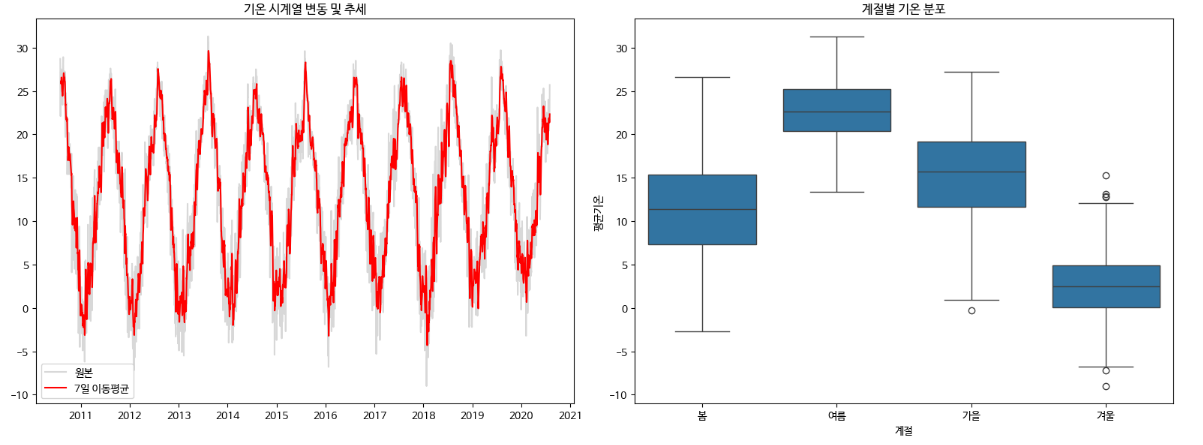

  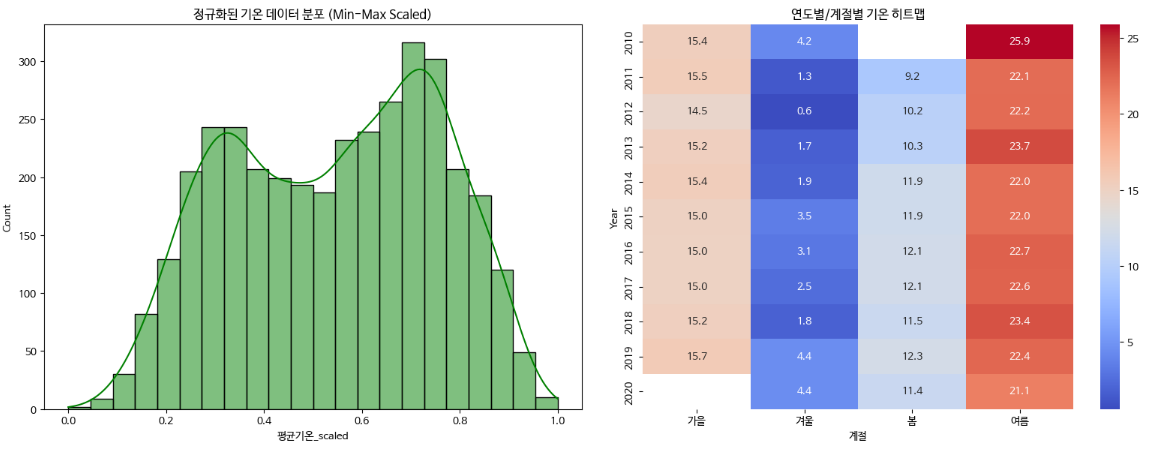



✅ 환경 설정 및 한글 폰트 로드 완료


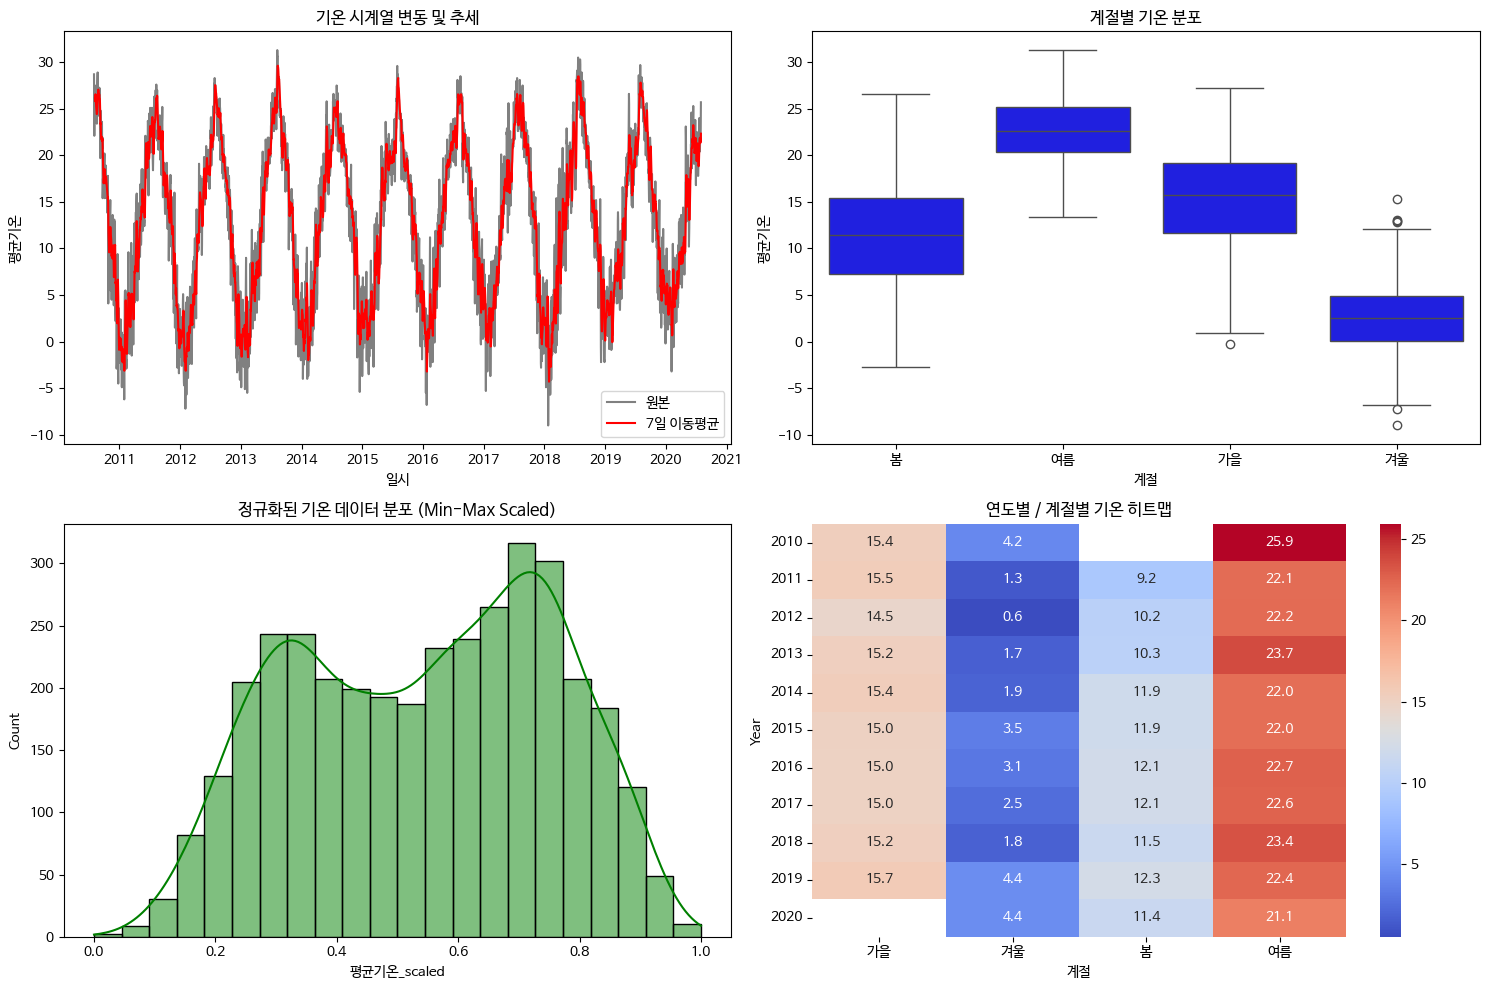

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import warnings

# 1. 환경 설정
def setup_environment():
    warnings.filterwarnings('ignore')

    # 1. 시스템에 나눔 폰트가 있는지 확인 및 설치
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        # Colab 등 리눅스 환경에서 폰트 설치
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 등록
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        # 윈도우 환경인 경우 'Malgun Gothic'
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 환경 설정 및 한글 폰트 로드 완료")

setup_environment()

# 2. 데이터 로드
def load_weather_data() :
  path = "https://github.com/dongupak/DataML/raw/main/csv/"
  df = pd.read_csv(path + 'weather.csv', encoding='CP949')
  df = df.interpolate(method='linear')
  return df

# 3. 데이터 정규화(Min-Max Scaling) : 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.
def min_max_scaling(series) :
  result = (series - series.min()) / (series.max() - series.min())
  return result

# 4. 시계열 핸들링 : 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.
def time_handling(df) :
  df['일시'] = pd.to_datetime(df['일시'])
  df.set_index('일시', inplace=True)

  df['7일_이동평균기온'] = df['평균기온'].rolling(window = 7).mean()

  df['Year'] = df.index.year
  df['Month'] = df.index.month

  def get_season(month) :
    if month in [3, 4, 5]:
      return '봄'
    elif month in [6, 7, 8] :
      return '여름'
    elif month in [9, 10, 11] :
      return '가을'
    else :
      return '겨울'

  df['계절'] = df['Month'].map(get_season)

  return df

# 5. 데이터 재구조화 : pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.
def re_structure(df) :
  season_group = df.groupby('계절')[['평균기온', '최대풍속']].mean()
  season_group = season_group.reindex(['봄', '여름', '가을', '겨울'])

  year_pivot = df.pivot_table(index = 'Year', columns = '계절', values = '평균기온', aggfunc = 'mean')

  return season_group, year_pivot

# 6. 시각화 함수
def visualize_data(df, season_group, year_pivot) :
  plt.figure(figsize=(15, 10))

  # 기온 시계열 변동 및 추세
  plt.subplot(2, 2, 1)
  sns.lineplot(data = df, x = df.index, y = '평균기온', label = '원본', color = 'gray')
  sns.lineplot(data = df, x = df.index, y='7일_이동평균기온', label = '7일 이동평균', color = 'red')
  plt.title("기온 시계열 변동 및 추세")
  plt.legend()

  # 계절별 기온 분포
  plt.subplot(2, 2, 2)
  sns.boxplot(data = df, x = '계절', y = '평균기온', order = ['봄', '여름', '가을', '겨울'], color = 'blue')
  plt.title("계절별 기온 분포")
  plt.xlabel('계절')
  plt.ylabel('평균기온')

  # 정규화된 기온 데이터 분포 (Min-Max Scaled)
  plt.subplot(2, 2, 3)
  df['평균기온_scaled'] = min_max_scaling(df['평균기온'])
  sns.histplot(data = df, x = '평균기온_scaled', kde = True, color = 'green')
  plt.title("정규화된 기온 데이터 분포 (Min-Max Scaled)")
  plt.xlabel('평균기온_scaled')
  plt.ylabel('Count')

  # 연도별 / 계절별 기온 히트맵
  plt.subplot(2, 2, 4)
  sns.heatmap(year_pivot, annot = True, fmt = ".1f", cmap = "coolwarm")
  plt.title("연도별 / 계절별 기온 히트맵")

  plt.tight_layout()
  plt.show()

# 7. 엑셀 내보내기 (To Excel): 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.
def to_excel(df, season_group, year_pivot) :
  with pd.ExcelWriter("weather_analysis_report.xlsx") as f :
    df.to_excel(f, sheet_name = '전처리 데이터')
    season_group.to_excel(f, sheet_name = '계절별 통계')
    year_pivot.to_excel(f, sheet_name = '연도별 피벗')

def main() :
  # 데이터 로드
  df = load_weather_data()
  # 시계열 핸들링
  df = time_handling(df)
  # 데이터 재구조화
  season_group, year_pivot = re_structure(df)
  # 시각화 출력, 데이터 정규화
  visualize_data(df, season_group, year_pivot)
  # 엑셀 저장
  to_excel(df, season_group, year_pivot)

if __name__ == "__main__" :
  main()
